# Figure 2: Training

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/app/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

/app/.venv/lib/python3.9/site-packages/datajoint/plugin.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-17 13:04:19,713][INFO]: Connecting admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
[2026-02-17 13:04:19,915][INFO]: Connected admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema.session_metrics import SessionMetrics
from vr4mice.analysis.analysis import style
from vr4mice.analysis.utils import get_training_stage_per_mouse
from vr4mice.analysis.stats import plot_training_stats_heatmap

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

style()

/app/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
save_fig_path = "notebooks/Paper_figures/Figure_output/"

# Fetch data and transform into dataframe

In [6]:
# could maybe move this out into a function since it because a bit of a long fetch call
data = []
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Groups() * vr4mice.Labels() & (vr4mice.Dataset() & f'session_label = "{stage}"')).fetch("dataset", as_dict=True)
    for d in training:
        
        dataset_name = d["dataset"]
        print(dataset_name)
        df = pd.DataFrame((SessionMetrics() & f'dataset = "{dataset_name}"').fetch(as_dict = True))
        split_d = dataset_name.split("_")
        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = stage
        df["lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]
        data.append(df)
big_df = pd.concat(data)  
 
big_df["session_increment"] = (
    big_df.groupby("mouse_name")["dataset"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

# remove failed session need to correct in datajoint - there was a second attempt run I need to correct its label
big_df = big_df [big_df.dataset != "Lemming_2024-08-09_1"].copy()
combined_training_df = []
for mouse_name in big_df.mouse_name.unique():
   tmp_df = get_training_stage_per_mouse(big_df, mouse_name)
   combined_training_df.append(tmp_df)
session_df = pd.concat(combined_training_df)

31726_2025-02-06_1
31726_2025-02-07_1
31726_2025-02-10_1
31726_2025-02-11_1
31726_2025-02-12_1
31726_2025-02-13_1
31728_2025-02-06_1
31728_2025-02-07_1
31728_2025-02-10_1
31728_2025-02-11_1
31728_2025-02-12_1
31728_2025-02-13_1
J729_2024-11-09_1
J729_2024-11-10_1
J729_2024-11-11_1
J729_2024-11-12_1
J729_2024-11-13_1
J729_2024-11-14_1
J729_2024-11-15_1
J729_2024-11-16_1
J729_2024-11-17_1
J731_2024-11-09_1
J731_2024-11-10_1
J731_2024-11-11_1
J731_2024-11-12_1
J731_2024-11-13_1
J731_2024-11-14_1
J731_2024-11-15_1
J731_2024-11-16_1
J731_2024-11-17_1
Jacana_2024-07-28_1
Jacana_2024-07-29_2
Jacana_2024-07-30_1
Jacana_2024-07-31_1
Jacana_2024-08-01_1
Jacana_2024-08-02_1
Jacana_2024-08-05_2
Jacana_2024-08-06_1
Jacana_2024-08-07_1
Kiwi_2024-07-26_1
Kiwi_2024-07-27_1
Kiwi_2024-07-28_1
Kiwi_2024-07-29_1
Kiwi_2024-07-30_1
Kiwi_2024-07-31_1
Kiwi_2024-08-01_1
Lemming_2024-07-27_1
Lemming_2024-07-28_1
Lemming_2024-07-29_2
Lemming_2024-07-30_1
Lemming_2024-07-31_1
Lemming_2024-08-01_1
Nightingale_2024

# Mean Training plots

In [7]:
# Linear Mixed Model (with Mouse)
lmm_model = smf.mixedlm("session_reward ~ C(num_train_stage)", 
                        data=session_df, groups=session_df["mouse_name"]).fit(method='bfgs')

# Ordinary Least Squares (without Mouse)
ols_model = smf.ols("session_reward ~ C(num_train_stage)", data=session_df).fit()

# Likelihood Ratio Test
lr_stat = 2 * (lmm_model.llf - ols_model.llf)
p_val = stats.chi2.sf(lr_stat, df=1) # 1 degree of freedom for the random effect

print(f"LRT Statistic: {lr_stat:.4f}")
print(f"P-value for Mouse effect: {p_val:.4f}")

if p_val > 0.05:
    print("Justification: Mouse identity does not significantly improve the model. Independent ANOVA is valid.")
else:
    print("Caution: Mouse identity still explains significant variance.")

LRT Statistic: -27.5341
P-value for Mouse effect: 1.0000
Justification: Mouse identity does not significantly improve the model. Independent ANOVA is valid.


/app/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/app/.venv/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/app/.venv/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 1.070489
  warnings.warn(msg, ConvergenceWarning)
/app/.venv/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


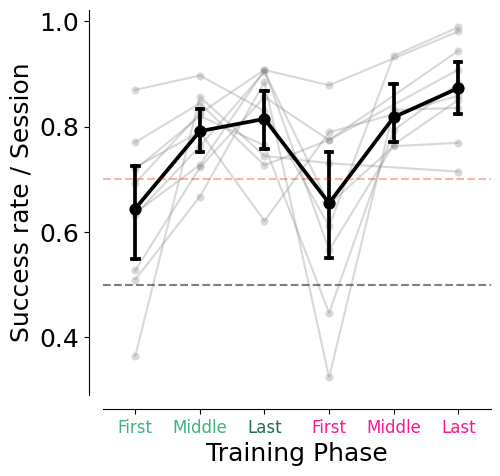

In [8]:
fig, ax = plt.subplots(1,1, figsize=(5,5))
plotting.plot_training_phases(ax, data=session_df, y="session_reward", ylabel="Success rate / Session")#, hue="mouse_name")

plt.savefig(save_fig_path + "figure2_reward_mouse.svg", transparent=True)

Anova                    df    sum_sq   mean_sq         F    PR(>F)
num_train_stage   1.0  0.147007  0.147007  8.130146  0.006192
Residual         53.0  0.958333  0.018082       NaN       NaN


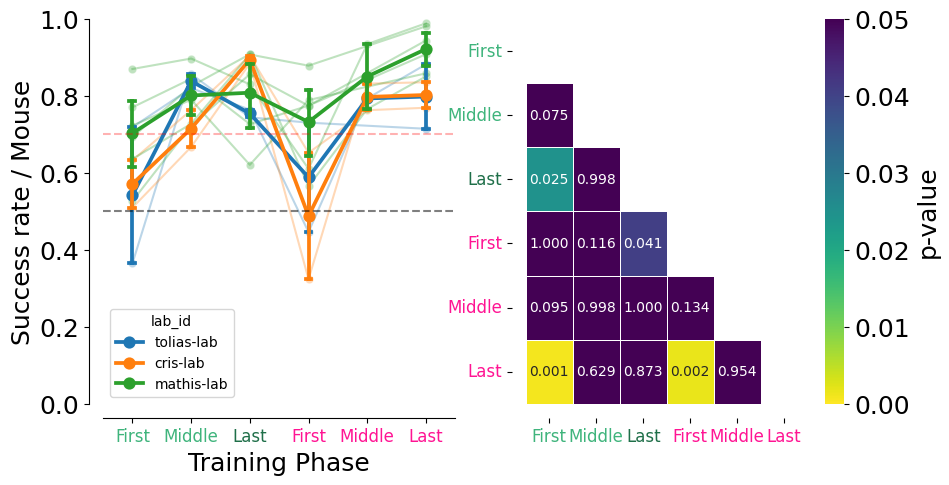

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

plotting.plot_training_phases(ax[0], data=session_df, y="session_reward", ylabel="Success rate / Mouse", ylim=(0,1), hue="lab_id")

results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_reward, session_df.num_train_stage, alpha=0.05)
plot_training_stats_heatmap(ax[1], results)

plt.savefig(save_fig_path + "figure2_success_rate.svg", transparent=True)

anova_rewarded = ols('session_reward ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova", table)

Anova                    df      sum_sq     mean_sq         F    PR(>F)
num_train_stage   1.0  138.855866  138.855866  8.328483  0.005634
Residual         53.0  883.637602   16.672408       NaN       NaN


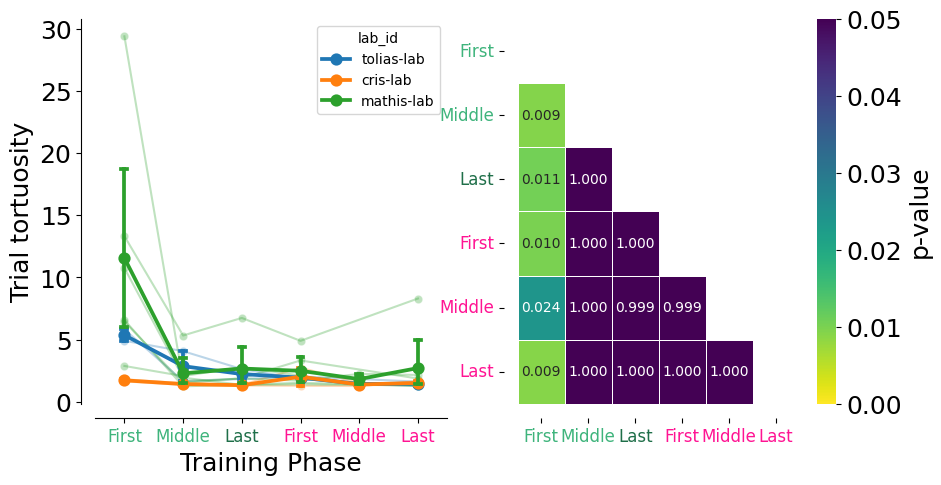

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_tortuosity", ylabel="Trial tortuosity", hue="lab_id")

results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_tortuosity, session_df.num_train_stage, alpha=0.05)
plot_training_stats_heatmap(ax [1], results)

plt.savefig(save_fig_path + "figure2_tortuosity.svg", transparent=True)

anova_rewarded = ols('session_tortuosity ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova", table)

Anova                    df       sum_sq     mean_sq          F    PR(>F)
num_train_stage   1.0   773.058815  773.058815  11.271117  0.001463
Residual         53.0  3635.142448   68.587593        NaN       NaN


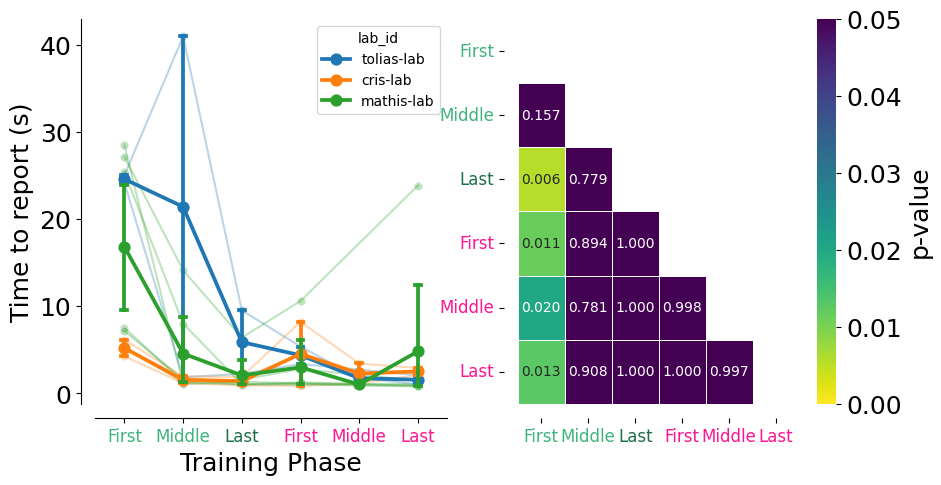

In [11]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_trial_duration", ylabel="Time to report (s)", hue="lab_id")

results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_trial_duration, session_df.num_train_stage, alpha=0.05)
plot_training_stats_heatmap(ax [1], results)

plt.savefig(save_fig_path + "figure2_trial_duration.svg", transparent=True)


anova_rewarded = ols('session_trial_duration ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova", table)

One-sample t-tests vs 0 (bias)
   num_train_stage   n  mean_bias    t_stat  df   p_value
0                0  10   0.024020  0.315024   9  0.759925
1                1  10   0.099960  1.243030   9  0.245264
2                2  10   0.072631  0.913433   9  0.384832
3                3  10   0.215386  3.028606   9  0.014279
4                4   5   0.156937  5.195691   4  0.006535
5                5  10   0.042537  0.990603   9  0.347763


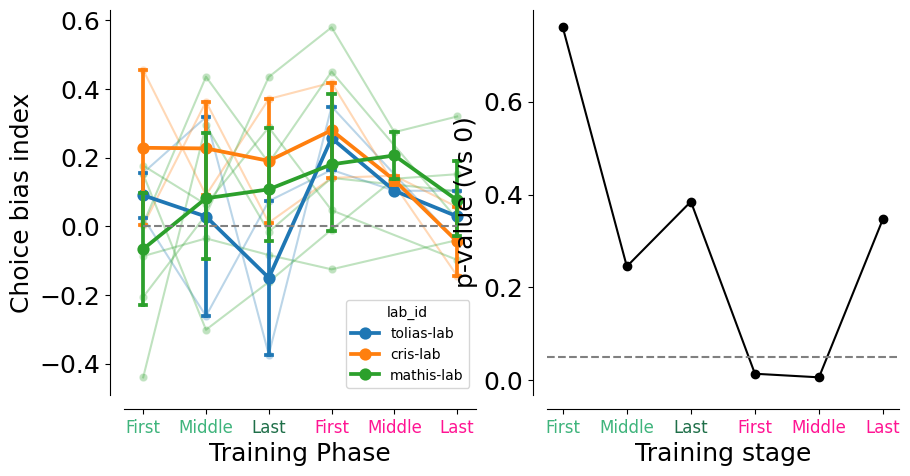

In [12]:
session_df["session_bias_index"] = 2 * session_df["session_bias"] - 1 

fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(
    ax[0],
    data=session_df,
    y="session_bias_index",
    ylabel="Choice bias index",
    ylim=(1, -1),
    hue="lab_id",
)
ax[0].hlines(0.0, xmin=0, xmax=session_df.num_train_stage.max(), color="grey", linestyle="--")

# One-sample t-test of bias against 0 (null) per training stage
stage_tests = []
for stage in sorted(session_df.num_train_stage.unique()):
    vals = session_df.loc[session_df.num_train_stage == stage, "session_bias_index"]
    t_stat, p_val = stats.ttest_1samp(vals, 0)
    stage_tests.append({
        "num_train_stage": stage,
        "n": len(vals),
        "mean_bias": vals.mean(),
        "t_stat": t_stat,
        "df": max(len(vals) - 1, 0),
        "p_value": p_val,
    })
stage_tests_df = pd.DataFrame(stage_tests)
print("One-sample t-tests vs 0 (bias)")
print(stage_tests_df)

# Plot p-values only (no bar/box)
ax[1].plot(stage_tests_df["num_train_stage"], stage_tests_df["p_value"], 
           marker="o", linestyle="-", color="k")
ax[1].axhline(0.05, color="grey", linestyle="--")
ax[1].set_xlabel("Training stage")
ax[1].set_ylabel("p-value (vs 0)")

# Define tick positions and labels
stage_positions = np.arange(6)
stage_labels = ["First", "Middle", "Last", "First", "Middle", "Last"]
stage_colors = [
    "#3FB47C",
    "#3FB47C",
    "#1F6F49",
    "#FF1493",
    "#FF1493",
    "#FF1493",
]
ax[1].set_xticks(stage_positions)
ax[1].set_xticklabels(stage_labels, rotation=0, fontsize=12)
# Color the x-tick labels
for j, label in enumerate(ax[1].get_xticklabels()):
    label.set_color(stage_colors[j])
    
plt.savefig(save_fig_path + "figure2_bias.svg", transparent=True)

In [13]:
session_df.num_train_stage.max()

5

One-sample t-tests vs 0 (bias) with FDR Correction
   num_train_stage   n   p_value  p_value_fdr  significant_fdr
0                0  10  0.759925     0.759925            False
1                1  10  0.245264     0.461798            False
2                2  10  0.384832     0.461798            False
3                3  10  0.014279     0.042837             True
4                4   5  0.006535     0.039213             True
5                5  10  0.347763     0.461798            False


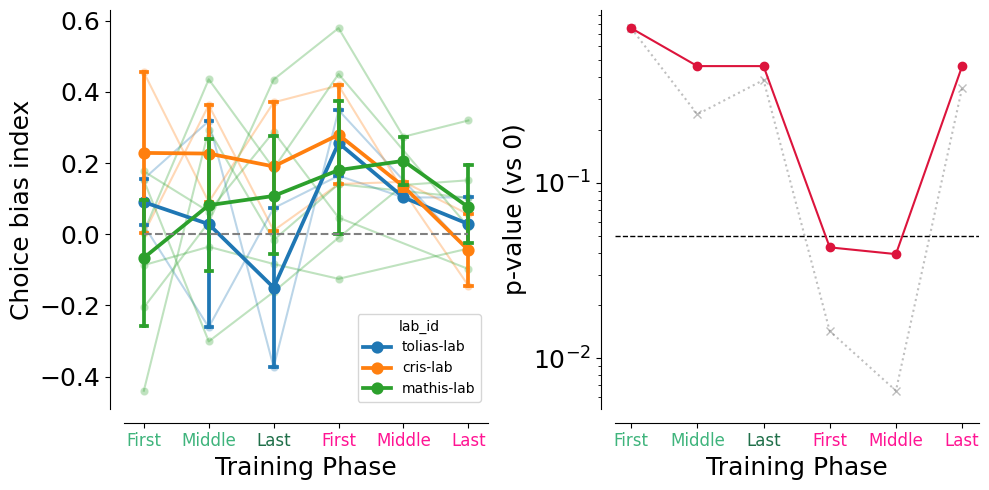

In [14]:
from statsmodels.stats.multitest import multipletests

session_df["session_bias_index"] = 2 * session_df["session_bias"] - 1 

# One-sample t-test of bias against 0 (null) per training stage
stage_tests = []
for stage in sorted(session_df.num_train_stage.unique()):
    vals = session_df.loc[session_df.num_train_stage == stage, "session_bias_index"].dropna()
    if len(vals) > 1:
        t_stat, p_val = stats.ttest_1samp(vals, 0)
        stage_tests.append({
            "num_train_stage": stage,
            "n": len(vals),
            "mean_bias": vals.mean(),
            "t_stat": t_stat,
            "df": len(vals) - 1,
            "p_value": p_val,
        })

stage_tests_df = pd.DataFrame(stage_tests)

# Apply False Discovery Rate (FDR) Correction
rejected, p_adjusted, _, _ = multipletests(stage_tests_df["p_value"], 
                                            alpha=0.05, 
                                            method='fdr_bh')

stage_tests_df["p_value_fdr"] = p_adjusted
stage_tests_df["significant_fdr"] = rejected

print("One-sample t-tests vs 0 (bias) with FDR Correction")
print(stage_tests_df[['num_train_stage', 'n', 'p_value', 'p_value_fdr', 'significant_fdr']])


fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Plot training phases
plotting.plot_training_phases(
    ax[0],
    data=session_df,
    y="session_bias_index",
    ylabel="Choice bias index",
    ylim=(1, -1),
    hue="lab_id",
)
ax[0].hlines(0.0, xmin=0, xmax=5, color="grey", linestyle="--")

# Plot p-values
# FDR-adjusted p-values in red and the raw ones in grey for comparison
ax[1].plot(stage_tests_df["num_train_stage"], stage_tests_df["p_value_fdr"],
           marker="o", linestyle="-", color="crimson", zorder=3)
ax[1].plot(stage_tests_df["num_train_stage"], stage_tests_df["p_value"],
           marker="x", linestyle=":", color="grey", alpha=0.5, zorder=2)

ax[1].axhline(0.05, color="black", linestyle="--", linewidth=1)
ax[1].set_xlabel("Training Phase")
ax[1].set_ylabel("p-value (vs 0)")
ax[1].set_yscale('log')

# Define tick positions and labels
stage_positions = np.arange(len(stage_tests_df))
stage_labels = ["First", "Middle", "Last", "First", "Middle", "Last"][:len(stage_tests_df)]
stage_colors = ["#3FB47C", "#3FB47C", "#1F6F49", "#FF1493", "#FF1493", "#FF1493"][:len(stage_tests_df)]

ax[1].set_xticks(stage_tests_df["num_train_stage"])
ax[1].set_xticklabels(stage_labels, rotation=0, fontsize=12)

# Color the x-tick labels
for j, label in enumerate(ax[1].get_xticklabels()):
    if j < len(stage_colors):
        label.set_color(stage_colors[j])

plt.tight_layout()
plt.savefig(save_fig_path + "figure2_bias.svg", transparent=True)

Anova                    df         sum_sq       mean_sq          F    PR(>F)
num_train_stage   1.0   88504.064246  88504.064246  22.752666  0.000015
Residual         53.0  206161.135754   3889.832750        NaN       NaN


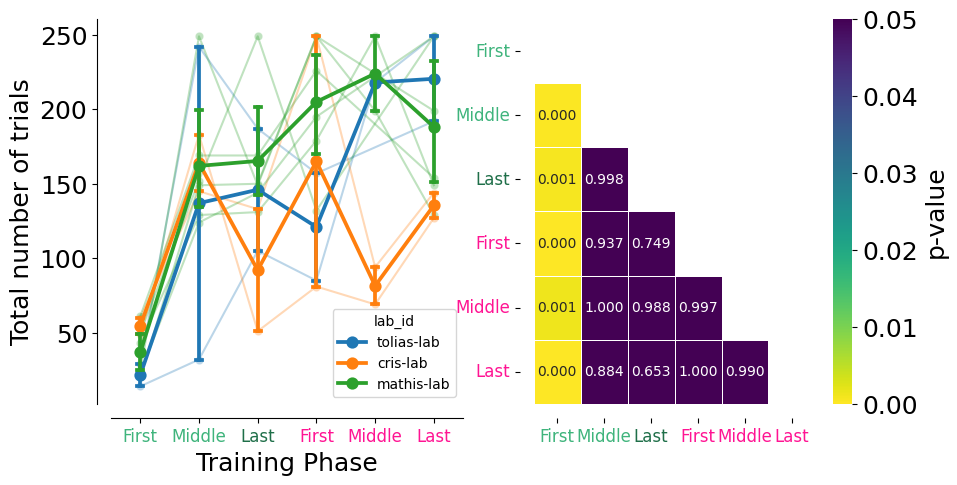

In [15]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_max_trial_number", ylabel="Total number of trials", hue="lab_id")

results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_max_trial_number, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax[1], results)

plt.savefig(save_fig_path + "figure2_max_trial_number.svg", transparent=True)

anova_rewarded = ols('session_max_trial_number ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova", table)

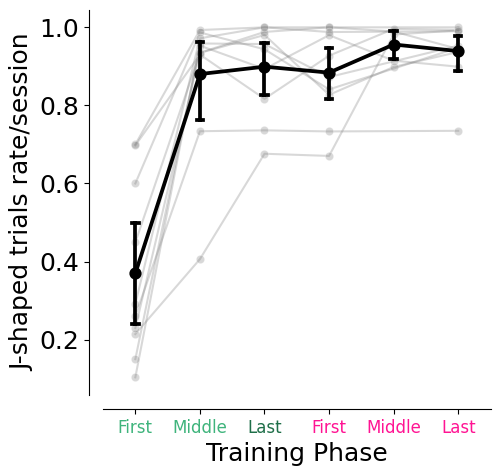

In [16]:
fig, ax = plt.subplots(1,1, figsize=(5,5))
plotting.plot_training_phases(ax, data=session_df, y="session_jshaped", ylabel="J-shaped trials rate/session")#, hue="mouse_name")

plt.savefig(save_fig_path + "figure2_jshaped_mouse.svg", transparent=True)

Anova                    df    sum_sq   mean_sq          F    PR(>F)
num_train_stage   1.0  1.238463  1.238463  29.529584  0.000001
Residual         53.0  2.222806  0.041940        NaN       NaN


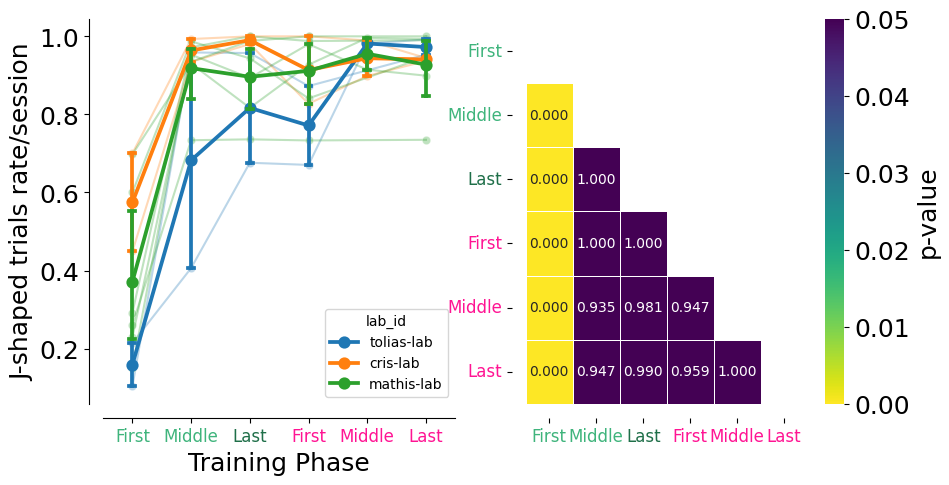

In [17]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_jshaped", ylabel="J-shaped trials rate/session", hue="lab_id")

results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_jshaped, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax[1], results)

plt.savefig(save_fig_path + "figure2_jshaped.svg", transparent=True)

anova_rewarded = ols('session_jshaped ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova", table)

## Training days and number of trials per mouse

In [18]:
training_days = big_df.groupby(["mouse_name"], as_index=False)["dataset"].nunique()
training_days["trials"] = big_df.groupby(["mouse_name"], as_index=False)["session_max_trial_number"].sum()["session_max_trial_number"]

In [19]:
training_days

,mouse_name,dataset,trials
0,31726,18,1522.0
1,31728,10,1567.0
2,J729,20,2274.0
3,J731,24,2320.0
4,Jacana,14,2227.0
5,Kiwi,12,1450.0
6,Lemming,10,1450.0
7,Nightingale,11,1216.0
8,Oribi,8,1196.0
9,Pheasant,7,1218.0


In [20]:
training_days.mean(numeric_only=True), training_days.sem(numeric_only=True)

(dataset      13.4
 trials     1644.0
 dtype: float64,
 dataset      1.758787
 trials     143.573984
 dtype: float64)

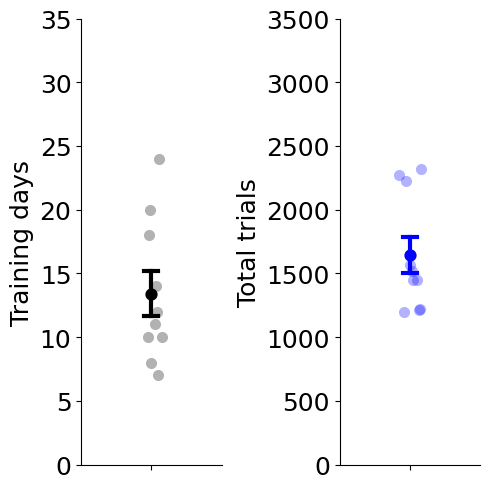

In [21]:
fig, ax = plt.subplots(1,2,figsize=(5,5))
sns.stripplot(
    data=training_days,
    y="dataset",
    color="black",
    jitter=True,
    size=8,
    alpha=0.3,
    zorder=0,
    ax=ax[0]
)

sns.pointplot(
    data=training_days,
    y="dataset",
    join=False,
    color="black",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=2,
    ax=ax[0]
)

 
ax[0].set_ylim(0,35)
ax[0].set_ylabel("Training days")

sns.stripplot(
    data=training_days,
    y="trials",
    color="blue",
    jitter=True,
    size=8,
    alpha=0.3,
    zorder=0,
    ax=ax[1]
)
sns.pointplot(
    data=training_days,
    y="trials",
    join=False,
    color="blue",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=2,
    ax=ax[1]
)

ax[1].set_ylim(0,3500)
ax[1].set_ylabel("Total trials")
plt.tight_layout()
plt.savefig(save_fig_path + "figure2_days_and_trials.svg", transparent=True)